In [1]:
!pip install imbalanced-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import OneHotEncoder, StandardScaler

from imblearn.over_sampling import SMOTE
from collections import Counter

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [3]:
# Load Processed Dataset
X_train = pd.read_csv("X_train.csv")
X_test = pd.read_csv("X_test.csv")

y_train = pd.read_csv("y_train.csv").squeeze()
y_test = pd.read_csv("y_test.csv").squeeze()

In [4]:
# Function for Evaluation - Instead of writing the same code repeatedly, create one reusable function
def evaluate_model(model, X_test, y_test):

    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:,1]
    else:
        y_prob = None

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    roc_auc = roc_auc_score(y_test, y_prob) if y_prob is not None else np.nan

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC AUC  : {roc_auc:.4f}")

    print("\nClassification Report\n")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(type(model).__name__)

    plt.show()

    return {
        "Model": type(model).__name__,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC_AUC": roc_auc
    }

## Logistic Regression

In [5]:
lr = LogisticRegression(random_state=42)
lr.fit(X_train, y_train)

LogisticRegression(random_state=42)

Accuracy : 0.8639
Precision: 0.6400
Recall   : 0.3404
F1 Score : 0.4444
ROC AUC  : 0.8102

Classification Report

              precision    recall  f1-score   support

           0       0.88      0.96      0.92       247
           1       0.64      0.34      0.44        47

    accuracy                           0.86       294
   macro avg       0.76      0.65      0.68       294
weighted avg       0.85      0.86      0.85       294



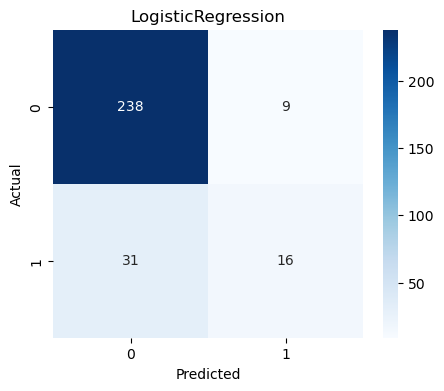

In [6]:
lr_result = evaluate_model(lr,X_test,y_test)

## RandomForest Classifier

In [9]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train,y_train)

RandomForestClassifier(random_state=42)

Accuracy : 0.8333
Precision: 0.4167
Recall   : 0.1064
F1 Score : 0.1695
ROC AUC  : 0.7888

Classification Report

              precision    recall  f1-score   support

           0       0.85      0.97      0.91       247
           1       0.42      0.11      0.17        47

    accuracy                           0.83       294
   macro avg       0.63      0.54      0.54       294
weighted avg       0.78      0.83      0.79       294



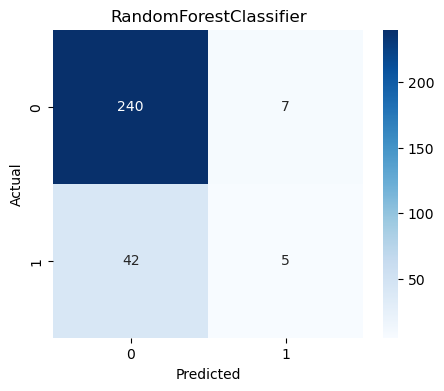

In [10]:
rf_result = evaluate_model(rf,X_test,y_test)

## Support Vector Machine

In [11]:
svm = SVC(probability=True,random_state=42)
svm.fit(X_train,y_train)

SVC(probability=True, random_state=42)

Accuracy : 0.8571
Precision: 0.7778
Recall   : 0.1489
F1 Score : 0.2500
ROC AUC  : 0.8139

Classification Report

              precision    recall  f1-score   support

           0       0.86      0.99      0.92       247
           1       0.78      0.15      0.25        47

    accuracy                           0.86       294
   macro avg       0.82      0.57      0.59       294
weighted avg       0.85      0.86      0.81       294



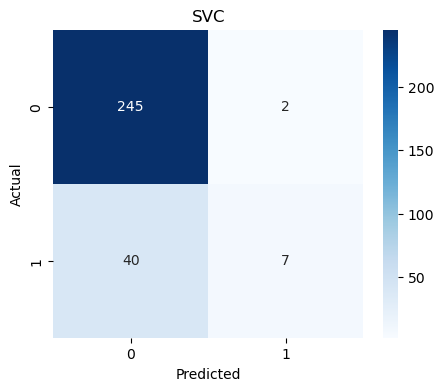

In [12]:
svm_result = evaluate_model(svm,X_test,y_test)

## K-Nearest neighbor

In [13]:
knn = KNeighborsClassifier()
knn.fit(X_train,y_train)

KNeighborsClassifier()

C:\Users\Lenovo\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\Lenovo\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\Lenovo\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Lenovo\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^

Accuracy : 0.8367
Precision: 0.4545
Recall   : 0.1064
F1 Score : 0.1724
ROC AUC  : 0.6181

Classification Report

              precision    recall  f1-score   support

           0       0.85      0.98      0.91       247
           1       0.45      0.11      0.17        47

    accuracy                           0.84       294
   macro avg       0.65      0.54      0.54       294
weighted avg       0.79      0.84      0.79       294



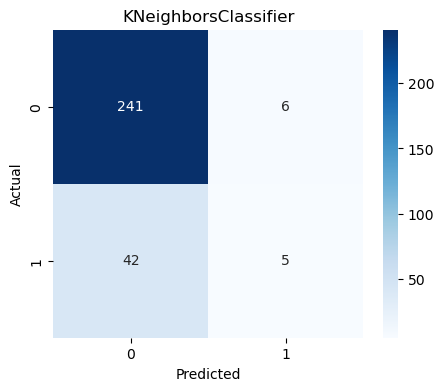

In [14]:
knn_result = evaluate_model(knn,X_test,y_test)

In [18]:
# Comparision of All Models
results = pd.DataFrame([
    lr_result,
    rf_result,
    svm_result,
    knn_result,
])

results

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,LogisticRegression,0.863946,0.640000,0.340426,0.444444,0.810233
1,RandomForestClassifier,0.833333,0.416667,0.106383,0.169492,0.788828
2,SVC,0.857143,0.777778,0.148936,0.250000,0.813851
3,KNeighborsClassifier,0.836735,0.454545,0.106383,0.172414,0.618055


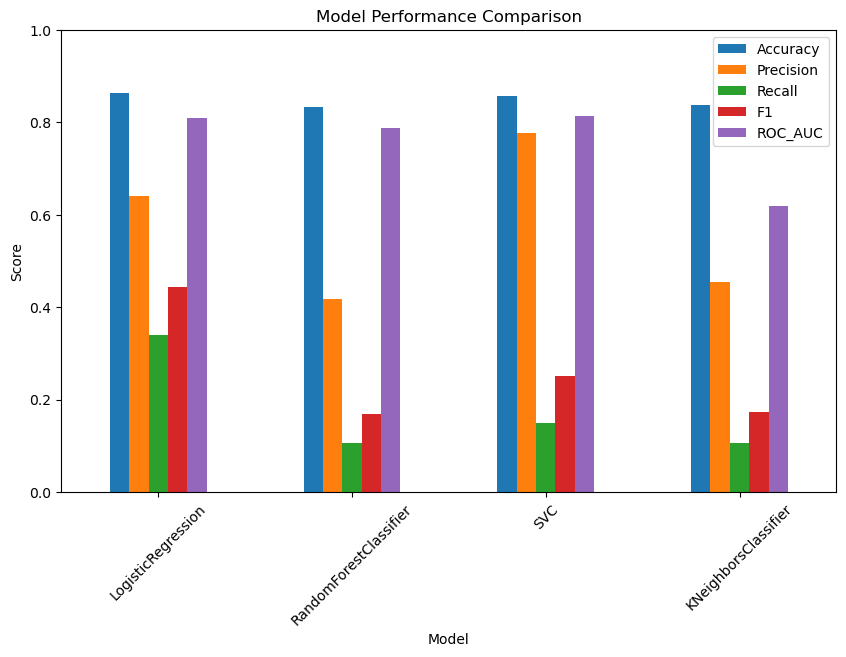

In [19]:
metrics = ["Accuracy", "Precision", "Recall", "F1", "ROC_AUC"]

results.set_index("Model")[metrics].plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.ylim(0, 1)

plt.show()

# ***Model Improvement***

## Class Imbalance using Class Weight

In [20]:
# Class Weight
class_weight="balanced"

In [21]:
# Train with Balanced Logistic Regression
lr_balanced = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)

lr_balanced.fit(
    X_train,
    y_train
)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

Accuracy : 0.7551
Precision: 0.3563
Recall   : 0.6596
F1 Score : 0.4627
ROC AUC  : 0.8035

Classification Report

              precision    recall  f1-score   support

           0       0.92      0.77      0.84       247
           1       0.36      0.66      0.46        47

    accuracy                           0.76       294
   macro avg       0.64      0.72      0.65       294
weighted avg       0.83      0.76      0.78       294



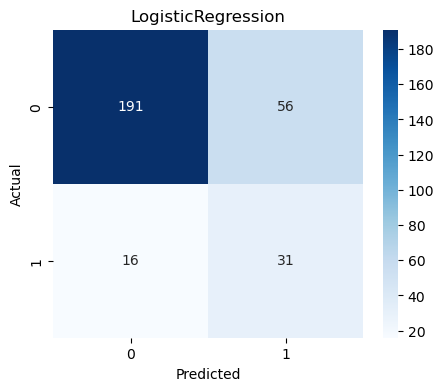

In [22]:
# Evaluate
lr_balanced_result = evaluate_model(
    lr_balanced,
    X_test,
    y_test
)

In [23]:
comparison = pd.DataFrame([
    lr_result,
    lr_balanced_result,
])

comparison

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,LogisticRegression,0.863946,0.640000,0.340426,0.444444,0.810233
1,LogisticRegression,0.755102,0.356322,0.659574,0.462687,0.803515


## ***Class Imbalance using SMOTE (Synthetic Minority Over-sampling Technique)***

In [24]:
print("Before SMOTE") 
print(Counter(y_train))

Before SMOTE
Counter({0: 986, 1: 190})


In [25]:
smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [26]:
print("After SMOTE")
print(Counter(y_train_smote))

After SMOTE
Counter({0: 986, 1: 986})


In [27]:
# Train Logistic Regression on SMOTE Data
lr_smote = LogisticRegression(
    random_state=42,
    max_iter=1000
)

lr_smote.fit(
    X_train_smote,
    y_train_smote
)

LogisticRegression(max_iter=1000, random_state=42)

Accuracy : 0.7721
Precision: 0.3780
Recall   : 0.6596
F1 Score : 0.4806
ROC AUC  : 0.7965

Classification Report

              precision    recall  f1-score   support

           0       0.92      0.79      0.85       247
           1       0.38      0.66      0.48        47

    accuracy                           0.77       294
   macro avg       0.65      0.73      0.67       294
weighted avg       0.84      0.77      0.79       294



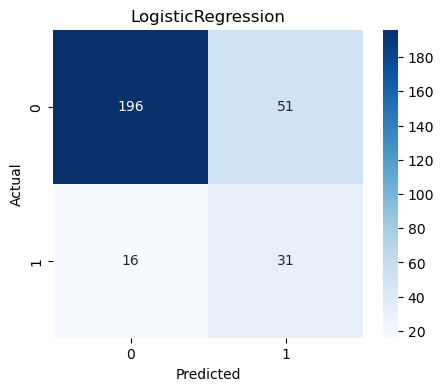

In [28]:
# Evaluate
lr_smote_result = evaluate_model(
    lr_smote,
    X_test,
    y_test
)

In [29]:
comparison_lr = pd.DataFrame([
    lr_result,
    lr_balanced_result,
    lr_smote_result
])

comparison_lr

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,LogisticRegression,0.863946,0.640000,0.340426,0.444444,0.810233
1,LogisticRegression,0.755102,0.356322,0.659574,0.462687,0.803515
2,LogisticRegression,0.772109,0.378049,0.659574,0.480620,0.796451


In [30]:
# Cross-Validation
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    lr_smote,
    X_train_smote,
    y_train_smote,
    cv=5, # k-fold split
    scoring="f1"
)

print(scores)
print("Mean F1:", scores.mean())

[0.7518797  0.77966102 0.80203046 0.82531646 0.81012658]
Mean F1: 0.7938028422049496


# ***Model Explainability & Insights***

In [31]:
# Extract Model Coefficients
coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": lr_smote.coef_[0]
})

coefficients.head()

,Feature,Coefficient
0,Age,-0.268159
1,DailyRate,-0.250211
2,DistanceFromHome,0.282356
3,Education,0.126934
4,EnvironmentSatisfaction,-0.471256


In [32]:
# Sort the Coefficients
coefficients = coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

coefficients

,Feature,Coefficient
23,BusinessTravel_Travel_Frequently,1.885000
43,OverTime_Yes,1.838151
34,JobRole_Laboratory Technician,1.634162
40,JobRole_Sales Representative,1.260288
24,BusinessTravel_Travel_Rarely,1.116157
42,MaritalStatus_Single,0.926361
26,Department_Sales,0.538000
11,NumCompaniesWorked,0.509894
33,JobRole_Human Resources,0.491086
21,YearsSinceLastPromotion,0.420510


In [33]:
# Top 10 Features Increasing Attrition
top_positive = coefficients.head(10)

top_positive

,Feature,Coefficient
23,BusinessTravel_Travel_Frequently,1.885000
43,OverTime_Yes,1.838151
34,JobRole_Laboratory Technician,1.634162
40,JobRole_Sales Representative,1.260288
24,BusinessTravel_Travel_Rarely,1.116157
42,MaritalStatus_Single,0.926361
26,Department_Sales,0.538000
11,NumCompaniesWorked,0.509894
33,JobRole_Human Resources,0.491086
21,YearsSinceLastPromotion,0.420510


In [34]:
# Top 10 Features Reducing Attrition
top_negative = coefficients.tail(10)

top_negative

,Feature,Coefficient
8,JobSatisfaction,-0.426394
4,EnvironmentSatisfaction,-0.471256
29,EducationField_Medical,-0.500647
22,YearsWithCurrManager,-0.523410
28,EducationField_Marketing,-0.601068
35,JobRole_Manager,-0.649602
27,EducationField_Life Sciences,-0.684007
16,TotalWorkingYears,-0.915129
30,EducationField_Other,-1.429837
37,JobRole_Research Director,-1.853467


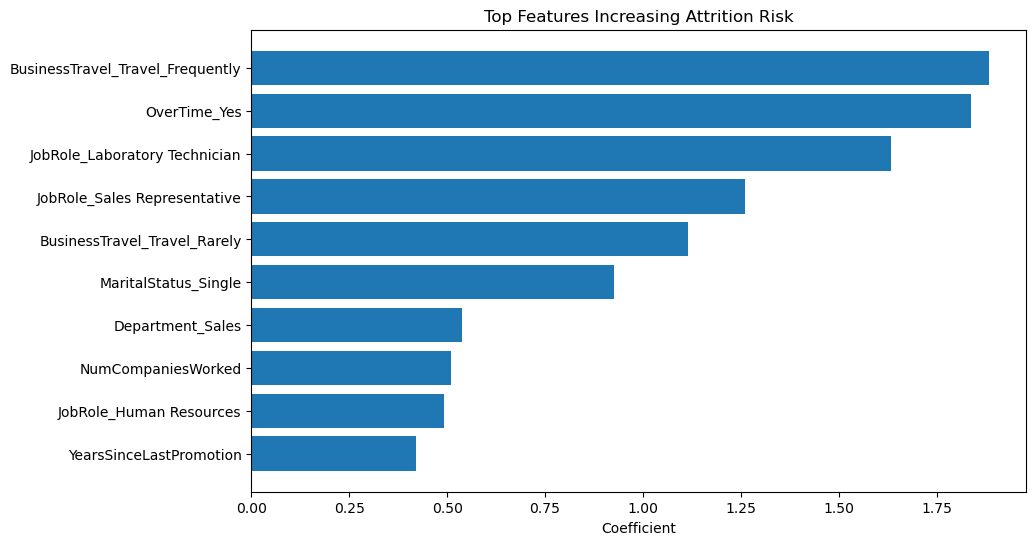

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    top_positive["Feature"],
    top_positive["Coefficient"]
)

plt.title("Top Features Increasing Attrition Risk")
plt.xlabel("Coefficient")

plt.gca().invert_yaxis()

plt.show()

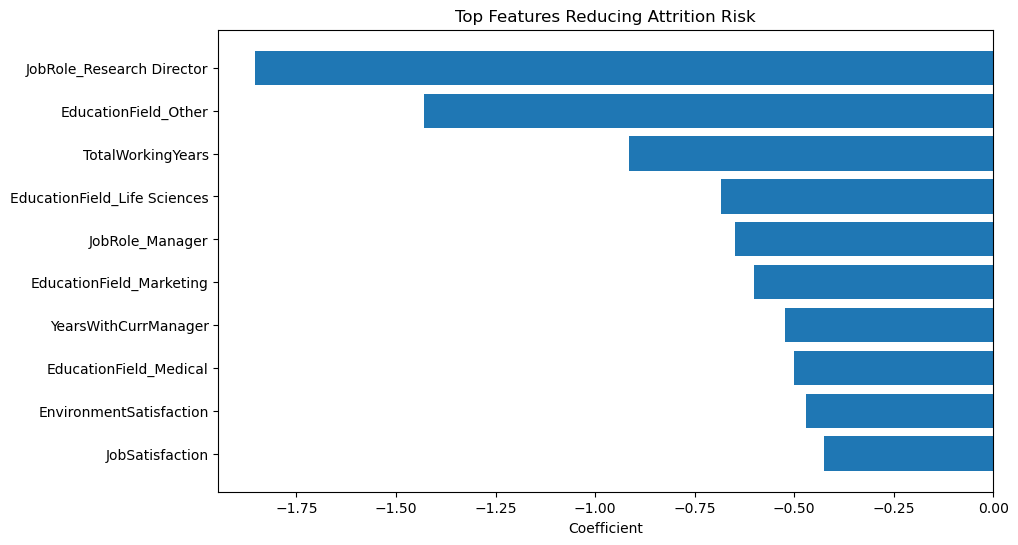

In [36]:
plt.figure(figsize=(10,6))

plt.barh(
    top_negative["Feature"],
    top_negative["Coefficient"]
)

plt.title("Top Features Reducing Attrition Risk")
plt.xlabel("Coefficient")

plt.show()

In [37]:
joblib.dump(lr_smote, "best_attrition_model.pkl")

['best_attrition_model.pkl']

# ***Prediction on New Data***

In [38]:
encoder = joblib.load("onehot_encoder.pkl")
scaler = joblib.load("standard_scaler.pkl")
numerical_features = joblib.load("numerical_features.pkl")
categorical_features = joblib.load("categorical_features.pkl")
model_columns = joblib.load("model_columns.pkl")
model = joblib.load("best_attrition_model.pkl")

In [39]:
new_employee = pd.DataFrame({

    'Age': [32],
    'BusinessTravel': ['Travel_Frequently'],
    'DailyRate': [850],
    'Department': ['Sales'],
    'DistanceFromHome': [15],
    'Education': [3],
    'EducationField': ['Marketing'],
    'EnvironmentSatisfaction': [2],
    'Gender': ['Female'],
    'HourlyRate': [55],
    'JobInvolvement': [2],
    'JobLevel': [2],
    'JobRole': ['Sales Executive'],
    'JobSatisfaction': [3],
    'MaritalStatus': ['Single'],
    'MonthlyIncome': [5400],
    'MonthlyRate': [12000],
    'NumCompaniesWorked': [4],
    'OverTime': ['Yes'],
    'PercentSalaryHike': [12],
    'PerformanceRating': [3],
    'RelationshipSatisfaction': [2],
    'StockOptionLevel': [0],
    'TotalWorkingYears': [8],
    'TrainingTimesLastYear': [2],
    'WorkLifeBalance': [2],
    'YearsAtCompany': [4],
    'YearsInCurrentRole': [2],
    'YearsSinceLastPromotion': [1],
    'YearsWithCurrManager': [2]

})

new_employee

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,32,Travel_Frequently,850,Sales,15,3,Marketing,2,Female,55,...,3,2,0,8,2,2,4,2,1,2


In [40]:
import pandas as pd
new_employee_encoded = pd.get_dummies(
    new_employee,
    drop_first=True
)

new_employee_encoded = new_employee_encoded.reindex(
    columns=X_train.columns,
    fill_value=0
)

new_employee_scaled = new_employee_encoded.copy()

cols_to_scale = scaler.feature_names_in_

new_employee_scaled[cols_to_scale] = scaler.transform(new_employee_encoded[cols_to_scale])

prediction = lr_smote.predict(
    new_employee_scaled
)

probabilities = lr_smote.predict_proba(new_employee_scaled)
leave_prob = probabilities[0][1] * 100  # Probability of class 1 (Leave)

if leave_prob > 70:
    risk = "High Risk"
elif leave_prob > 40:
    risk = "Medium Risk"
else:
    risk = "Low Risk"

result = pd.DataFrame({
    "Prediction": [
        "Leave" if prediction[0] == 1 else "Stay"
    ],
    "Leave Probability (%)": [
        round(leave_prob,2)
    ],
    "Risk Level": [risk]
})

result

,Prediction,Leave Probability (%),Risk Level
0,Stay,36.13,Low Risk
